In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import math

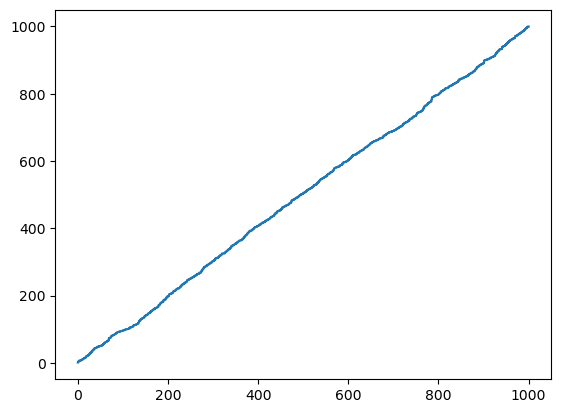

In [3]:
def metoda1(lam=2, T=100):
    I, t = 0, 0
    jumps = []
    while True:
        U = np.random.uniform(0,1)
        t = t - np.log(U) / lam
        if t > T:
            break
        else:
            I = I + 1
            SI = t
            jumps.append(SI)
    return jumps

F = metoda1(lam=1 ,T=1000)
x_arg = np.linspace(0, 1000, len(F))
plt.step(x_arg, F)
plt.show()

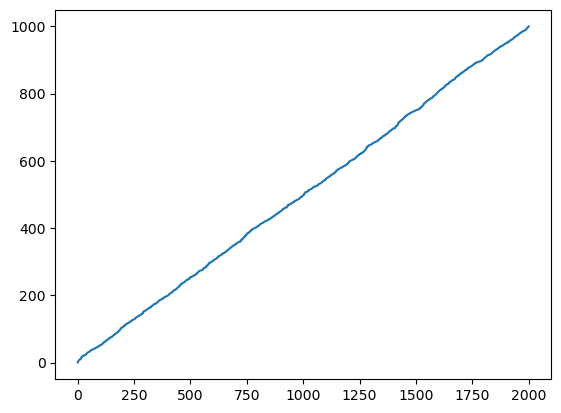

In [4]:
def metoda2(lam=2, T=1000):
    n = np.random.poisson(lam * T)
    U = np.random.uniform(0, T, n)
    U.sort()
    return U

F = metoda2()
x_arg = np.linspace(0, 2000, len(F))
plt.plot(x_arg, F)
plt.show()

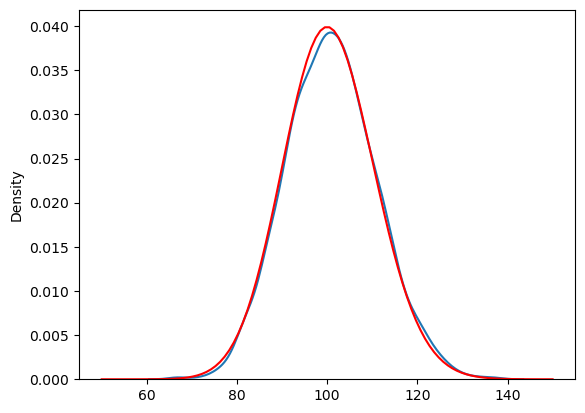

In [5]:
def Proces(t, lam=2):
    I, czas = 0, 0
    while czas < t:
        U = np.random.uniform(0,1)
        czas = czas - np.log(U) / lam
        I = I + 1
    return I

skoki = [Proces(50) for _ in range(5000)]
sn.kdeplot(skoki)
lam = 2
t_arg = 50
P = []
for n in range(50, 150):
    P.append(np.exp(-lam * t_arg) * ((lam * t_arg)**n) / math.factorial(n))
plt.plot(np.linspace(50, 150, len(P)), P, 'r')
plt.show()

<Axes: ylabel='Density'>

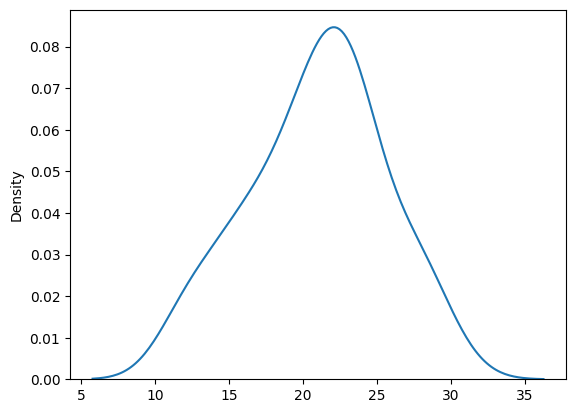

In [ ]:
def generate_poisson(lam):

    def small_lam(lda):
        n, a = 1, 1
        while a >= np.exp(-lda):
            U = np.random.uniform(0,1)
            a = a * U
            n = n + 1
        return n - 1
    
    if lam < 10:
        return small_lam(lam)
    
    else:
        m = math.floor(0.875 * lam)
        Y = np.random.gamma(m, 1)

        if Y <= lam:
            Z = small_lam(lam - Y)
            return m + Z
        
        else:
            return np.random.binomial(m-1, lam/Y)


d = [generate_poisson(20) for _ in range(50)]
sn.kdeplot(d)


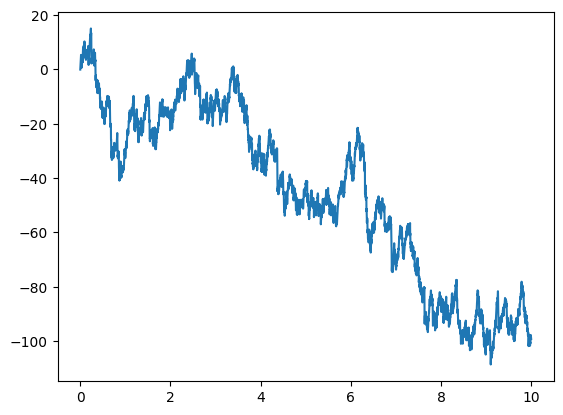

In [ ]:
def skompensowany(lam=2, T=100):
    I, t = 0, 0
    N = []
    while True:
        U = np.random.uniform(0,1)
        t = t - np.log(U) / lam
        if t > T:
            break
        else:
            I = I + 1
            N.append(I - lam * t)
    return N

F = skompensowany(lam=3 ,T=2000)
x_arg = np.linspace(0, 10, len(F))
plt.plot(x_arg, F)
plt.show()